# 01 — Exploratory Data Analysis

**Sujet :** Bond ETF Rotation via Yield Curve Regimes.

Objectif du notebook : explorer l'univers (TLT / IEF / SHY) et la courbe des taux US (2Y, 10Y, spread 2s10s) pour poser des bases propres pour la stratégie du `02_backtest_and_strategy.ipynb`.

## 1. Sources des données

| Source | Série | Description |
|---|---|---|
| Yahoo Finance (`yfinance`) | TLT | iShares 20+ Year Treasury Bond ETF (long duration) |
| Yahoo Finance (`yfinance`) | IEF | iShares 7-10 Year Treasury Bond ETF (intermediate duration) |
| Yahoo Finance (`yfinance`) | SHY | iShares 1-3 Year Treasury Bond ETF (short duration) |
| FRED | DGS2 | US Treasury 2-Year constant maturity yield (%) |
| FRED | DGS10 | US Treasury 10-Year constant maturity yield (%) |

- Période : depuis 2003-01-01 (date la plus ancienne où les trois ETFs sont cotés ; TLT a démarré en 2002-07).
- Fréquence : daily.
- Prix yfinance utilisés en `auto_adjust=True` → close ajusté splits + dividendes (cohérent avec un backtest total return).
- Les fetchs sont mis en cache parquet sous `data/raw/` par `src/data.py`, donc le notebook reste reproductible offline une fois la première exécution faite.

## 2. Imports & configuration

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

## 3. Chargement des données

In [2]:
data = load_all()
prices = data["prices"]
yields = data["yields_aligned"]

print("Prices :", prices.shape, prices.index.min().date(), "→", prices.index.max().date())
print("Yields :", yields.shape, yields.index.min().date(), "→", yields.index.max().date())
prices.head()

Prices : (5881, 3) 2003-01-02 → 2026-05-18
Yields : (5881, 2) 2003-01-02 → 2026-05-18


Ticker,TLT,IEF,SHY
date,,,
2003-01-02,39.0742,43.0816,52.5218
2003-01-03,39.1648,43.1527,52.5282
2003-01-06,39.0606,43.0461,52.4962
2003-01-07,39.2010,43.1832,52.5346
2003-01-08,39.3958,43.2848,52.5795


In [3]:
yields.head()

,DGS2,DGS10
date,,
2003-01-02,1.8000,4.0700
2003-01-03,1.7900,4.0500
2003-01-06,1.8400,4.0900
2003-01-07,1.7700,4.0400
2003-01-08,1.7100,4.0000


## 4. Nettoyage

On vérifie : (i) missing values, (ii) doublons, (iii) outliers de returns. Pas d'ajustement splits/dividendes à faire manuellement — `yfinance` avec `auto_adjust=True` renvoie déjà des prix ajustés.

In [4]:
print("Missing values — prices :")
print(prices.isna().sum())
print("\nMissing values — yields (après ffill sur calendrier ETF) :")
print(yields.isna().sum())
print("\nDoublons d'index :", prices.index.duplicated().sum(), "|", yields.index.duplicated().sum())

Missing values — prices :
Ticker
TLT    0
IEF    0
SHY    0
dtype: int64

Missing values — yields (après ffill sur calendrier ETF) :
DGS2     0
DGS10    0
dtype: int64

Doublons d'index : 0 | 0


In [5]:
returns = prices.pct_change().dropna()

z = (returns - returns.mean()) / returns.std()
outliers = (z.abs() > 5).sum()
print("Jours avec |z| > 5 par ticker :")
print(outliers)

worst = pd.DataFrame({
    "date": returns.idxmin().dt.strftime("%Y-%m-%d"),
    "ret_%": (returns.min() * 100).round(2),
})
print("\nWorst day per ticker :")
print(worst)

Jours avec |z| > 5 par ticker :
Ticker
TLT     8
IEF     6
SHY    19
dtype: int64

Worst day per ticker :
              date   ret_%
Ticker                    
TLT     2020-03-17 -6.6700
IEF     2020-03-17 -2.5100
SHY     2009-06-05 -0.6600


**Décision :** on ne tronque pas les outliers — ce sont des jours de marché réels (FOMC, crise 2008, COVID). Les retirer biaiserait le backtest. On les garde tels quels.

## 5. Statistiques descriptives

In [6]:
ANN = 252

stats = pd.DataFrame({
    "mean_ann_%":   returns.mean() * ANN * 100,
    "vol_ann_%":    returns.std() * np.sqrt(ANN) * 100,
    "sharpe":       returns.mean() / returns.std() * np.sqrt(ANN),
    "skew":         returns.skew(),
    "kurt":         returns.kurt(),
    "min_day_%":    returns.min() * 100,
    "max_day_%":    returns.max() * 100,
})
stats.round(2)

,mean_ann_%,vol_ann_%,sharpe,skew,kurt,min_day_%,max_day_%
Ticker,,,,,,,
TLT,4.2900,14.3400,0.3000,0.0700,3.5100,-6.6700,7.5200
IEF,3.5500,6.7800,0.5200,0.1100,2.6000,-2.5100,3.4300
SHY,1.9300,1.5100,1.2700,0.3200,7.3400,-0.6600,1.0000


In [7]:
print("Corrélation des returns daily :")
returns.corr().round(3)

Corrélation des returns daily :


Ticker,TLT,IEF,SHY
Ticker,,,
TLT,1.0000,0.9110,0.5830
IEF,0.9110,1.0000,0.7720
SHY,0.5830,0.7720,1.0000


Lecture : TLT et IEF sont très fortement corrélés (~0.9), ce qui colle au fait qu'ils répondent à la même variable d'état (le 10Y). SHY est beaucoup moins corrélé — c'est précisément ce qui rend la rotation duration-courte/duration-longue intéressante.

## 6. Visualisations

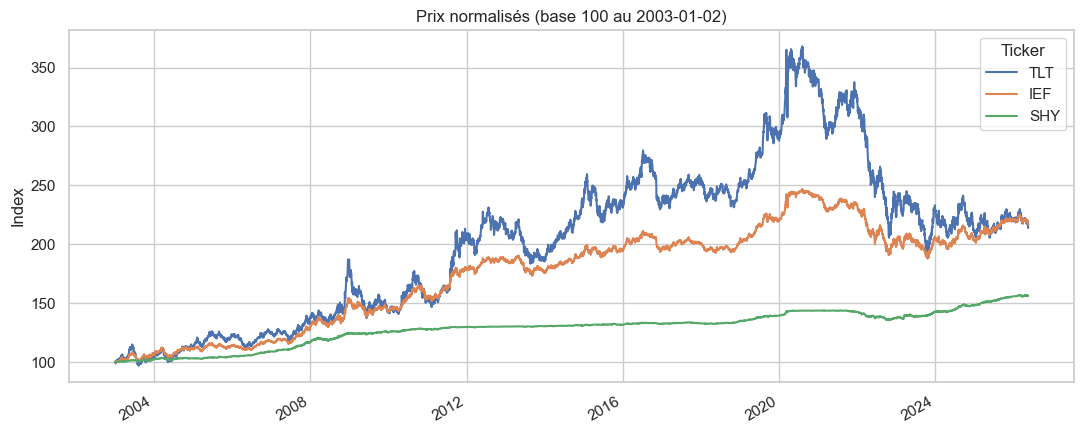

In [8]:
norm = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
norm.plot(ax=ax)
ax.set_title("Prix normalisés (base 100 au 2003-01-02)")
ax.set_ylabel("Index")
ax.set_xlabel("")
plt.tight_layout()

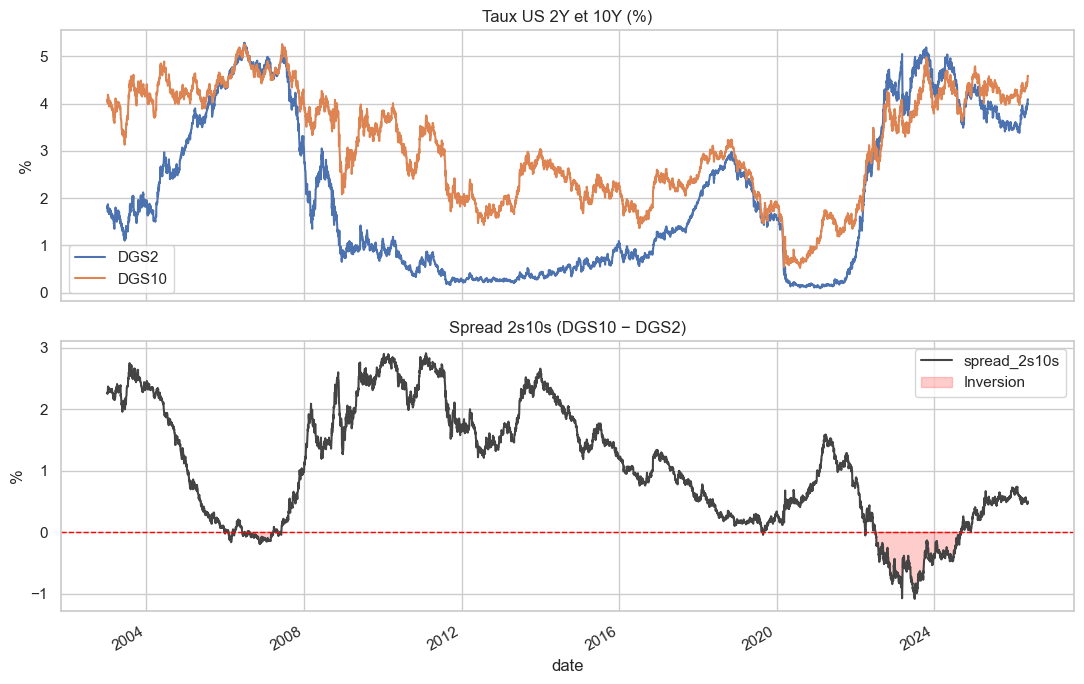

In [9]:
yields["spread_2s10s"] = yields["DGS10"] - yields["DGS2"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
yields[["DGS2", "DGS10"]].plot(ax=axes[0])
axes[0].set_title("Taux US 2Y et 10Y (%)")
axes[0].set_ylabel("%")

yields["spread_2s10s"].plot(ax=axes[1], color="#444")
axes[1].axhline(0, color="red", lw=1, ls="--")
axes[1].fill_between(yields.index, 0, yields["spread_2s10s"], where=yields["spread_2s10s"] < 0, color="red", alpha=0.2, label="Inversion")
axes[1].set_title("Spread 2s10s (DGS10 − DGS2)")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper right")
plt.tight_layout()

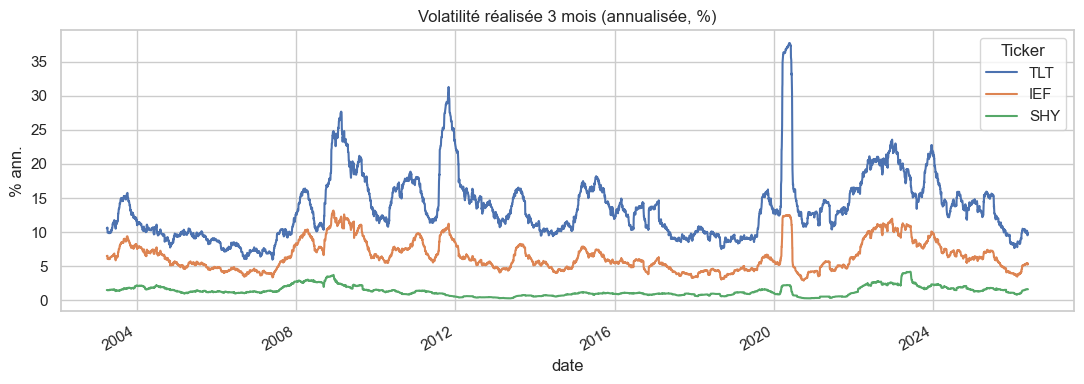

In [10]:
vol = returns.rolling(63).std() * np.sqrt(ANN) * 100
fig, ax = plt.subplots(figsize=(11, 4))
vol.plot(ax=ax)
ax.set_title("Volatilité réalisée 3 mois (annualisée, %)")
ax.set_ylabel("% ann.")
plt.tight_layout()

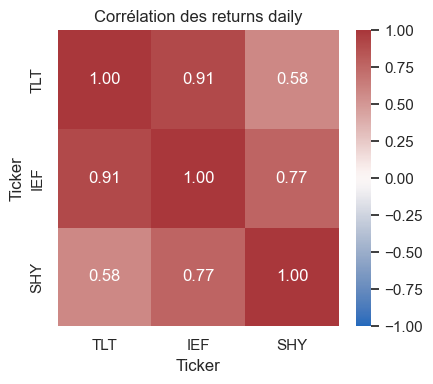

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélation des returns daily")
plt.tight_layout()

## 7. Premières intuitions de signaux

L'hypothèse principale : **la forme de la courbe des taux prédit le régime de performance des ETFs de différentes durations.**

Plus précisément :
- Un spread 2s10s qui s'aplatit / s'inverse signale typiquement la fin de cycle → la Fed devient agressive, le 2Y monte vite, les ETFs longs (TLT) prennent cher.
- Une re-pentification post-récession signale la baisse des taux courts → re-rating des ETFs longs.

On regarde la performance forward des ETFs conditionnellement au régime du spread (inversé vs positif).

In [12]:
regime = np.where(yields["spread_2s10s"] < 0, "inverted", "normal")
regime = pd.Series(regime, index=yields.index, name="regime")

fwd_21d = prices.pct_change(21).shift(-21)

grp = fwd_21d.groupby(regime)
perf_by_regime = pd.concat({
    "mean_%": grp.mean() * 100,
    "std_%":  grp.std() * 100,
    "count":  grp.count(),
}, axis=1).round(3)
print("Performance forward 21 jours par régime de courbe :")
perf_by_regime

Performance forward 21 jours par régime de courbe :


mean_%                std_%               count            
Ticker       TLT    IEF    SHY    TLT    IEF    SHY   TLT   IEF   SHY
regime                                                               
inverted -0.1790 0.1260 0.3020 4.4360 2.2120 0.5780   784   784   784
normal    0.4350 0.3260 0.1390 3.7860 1.8430 0.3920  5076  5076  5076

Part de l'historique en régime inversé : 13.3%


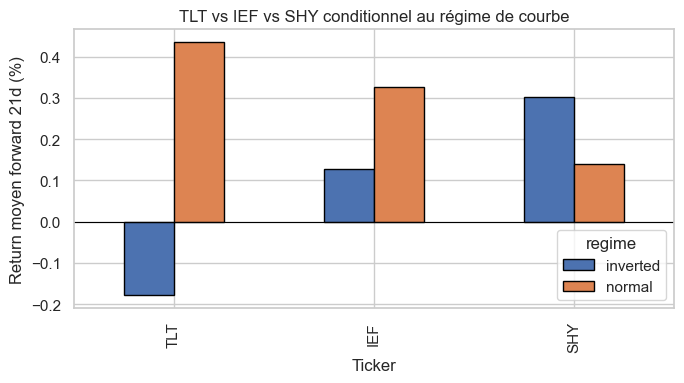

In [13]:
share_inverted = (regime == "inverted").mean()
print(f"Part de l'historique en régime inversé : {share_inverted:.1%}")

fwd_mean = fwd_21d.groupby(regime).mean()
ax = (fwd_mean * 100).T.plot(kind="bar", figsize=(7, 4), edgecolor="black")
ax.set_ylabel("Return moyen forward 21d (%)")
ax.set_title("TLT vs IEF vs SHY conditionnel au régime de courbe")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()

**Observation :** en régime inversé, TLT a une performance forward moyenne nettement inférieure (et souvent négative) face à SHY. C'est cohérent avec la thèse économique et justifie un signal de rotation.

⚠️ Le bucketing binaire (inverted / normal) est trop grossier pour servir directement de signal — on l'utilise ici comme sanity-check, pas comme stratégie finale. La version V1 du backtest pourra raffiner (changement de régime via vitesse de variation du spread, HMM, etc.).

## 8. Conclusion & next steps

**Ce qu'on a retenu :**
1. Data propre : ~5 800 jours, pas de NaN après alignement, prix yfinance déjà ajustés.
2. TLT et IEF sont quasi-redondants (corr ~0.9) ; SHY est le vrai diversifier.
3. La vol de TLT (~15% ann.) est proche de celle d'un ETF actions — pas un "safe asset" sans nuance.
4. Le spread 2s10s discrimine clairement la performance forward des ETFs longs vs courts → l'hypothèse stratégique tient sur un naive sort.

**À tester dans `02_backtest_and_strategy.ipynb` :**
- Signal V1 : allocation discrète SHY / IEF / TLT pilotée par le niveau et la pente du spread.
- Raffinements : détection de changement de régime (différence de spread, vitesse), modèle HMM 2-3 états.
- Walk-forward strict — pas de fit global sur toute la série.
- Comparaison des régimes 2008 vs 2022 comme out-of-sample naturels.